##### Feladat (Példatár 1.18)

Az ábrán látható kör keresztmetszetű görbe rúd terhelése a $5 ~\mathrm{kNm}$ nyomaték a végkeresztmetszeten. Határozza meg a normálfeszültség értékét az $A$ és $B$ helyeken! Milyen $t$ távolságra helyezkedik el a $B$ ponttól sugár irányban a semleges tengely helye?

<img src="img/01.jpg" alt="Feladat" width=200px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
M_data = 5 # kNm
r_data = 200 # mm
d_data = 200 # mm

# Átváltás N, mm, MPa rendszerbe
M_data = M_data * 10**6 # Nmm

In [3]:
M, r, d = sp.symbols('M, r, d')

In [4]:
data = [(M, M_data),
        (r, r_data),
        (d, d_data)]

##### Görbületi sugár és a görbületi sugár irányába eső legnagyobb méret hányadosa

In [5]:
R = r + d/2
ratio = (R / d).subs(data)
display(Math(rf'\frac{{R}}{{d}} = {latex(ratio)} \quad \longrightarrow \quad \mathrm{{Grashof-képlet}} ~ I_0 ~ \mathrm{{használatával}}'))

<IPython.core.display.Math object>

##### Redukált másodrendű nyomaték számítása

In [6]:
chi = 1/4*(d/(2*R))**2 + 1/8*(d/(2*R))**4 + 5/64*(d/(2*R))**6 + 7/128*(d/(2*R))**8
display(Math(rf'\chi = {latex(chi)} = {latex(chi.subs(data))}'))

A = d**2*sp.pi/4
display(Math(rf'A = {latex(A)} = {latex(A.subs(data).evalf(7))} ~\mathrm{{mm^2}}'))

I_0 = R**2*A*chi
display(Math(rf'I_0 = R^2 \cdot A \cdot \chi = {latex(I_0.subs(data).evalf(9))} ~\mathrm{{mm^4}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Hajlítónyomaték A-C keresztmetszetben

In [7]:
# Pozitív előjel, mivel a rúd görbületét növeli
Mh = M

##### Grashof-képlet

In [8]:
def sigma(y):
    return Mh/(R*A) + Mh/I_0 * y * R/(R+y)

y = sp.Symbol('y')

display(Math(rf'\sigma_{{z}}(y) = {latex(sigma(y))}'))

display(Latex('Behelyettesítve:'))

display(Math(rf'\sigma_{{z}}(y) = {latex(sigma(y).subs(data).evalf(4))}'))

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

##### Értéke a nevezetes pontokban

In [9]:
# A pont
y_A = -d/2

sigma_A = sigma(y_A).subs(data).evalf(6)
display(Math(rf'\sigma_{{z}}(y_A) = {latex(sigma_A)} ~\mathrm{{MPa}}'))

# Súlypont (S)
y_S = 0

sigma_S = sigma(y_S).subs(data).evalf(6)
display(Math(rf'\sigma_{{z}}(y_S) = {latex(sigma_S)} ~\mathrm{{MPa}}'))

# B pont
y_B = d/2

sigma_B = sigma(y_B).subs(data).evalf(6)
display(Math(rf'\sigma_{{z}}(y_B) = {latex(sigma_B)} ~\mathrm{{MPa}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Normálfeszültség eloszlása

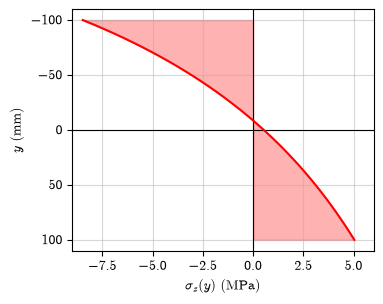

In [10]:
sigma_sym = sigma(y).subs(data)

sigma_num = sp.lambdify(y, sigma_sym)

y_vals = np.linspace(float(y_A.subs(data)), float(y_B.subs(data)))
sigma_vals = sigma_num(y_vals)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(sigma_vals, y_vals, color='red', zorder=5)
plt.fill_betweenx(y_vals, sigma_vals, 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\sigma_z(y) ~ \mathrm{(MPa)}$')
plt.ylabel(r'$y ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-9, 6)
plt.ylim(-110, 110)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('normalfeszultseg_eloszlas.pdf')
plt.show()

##### Semleges tengely helye

In [11]:
# Ahol a feszültség zérus
eq = sigma_sym
sol  = sp.solve(eq, y)
ysol = sol[0]

display(Math(rf'y^* = {latex(round(ysol, 3))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

In [12]:
# Távolság a 'B' ponttól
t = ( d/2 + sp.Abs(ysol) ).subs(data)
display(Math(rf't = {latex(round(t, 3))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>